# Secondary Plots

Contains plots that build on data cached for plots from `provenance_explorer.analysis.*`.

In [1]:
from provenance_explorer.registry.registry_all import WORK, get_big_registry
from provenance_explorer.registry.attack_registry import ALL_REGISTRIES
from provenance_explorer.plotting import apply_style, palette

import json
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

apply_style()

cache_path = WORK / "provenance-explorer-cache"

## CDM Type distribution bar chart

Requires `.correctness.data_model_types_plot` to be cached. 

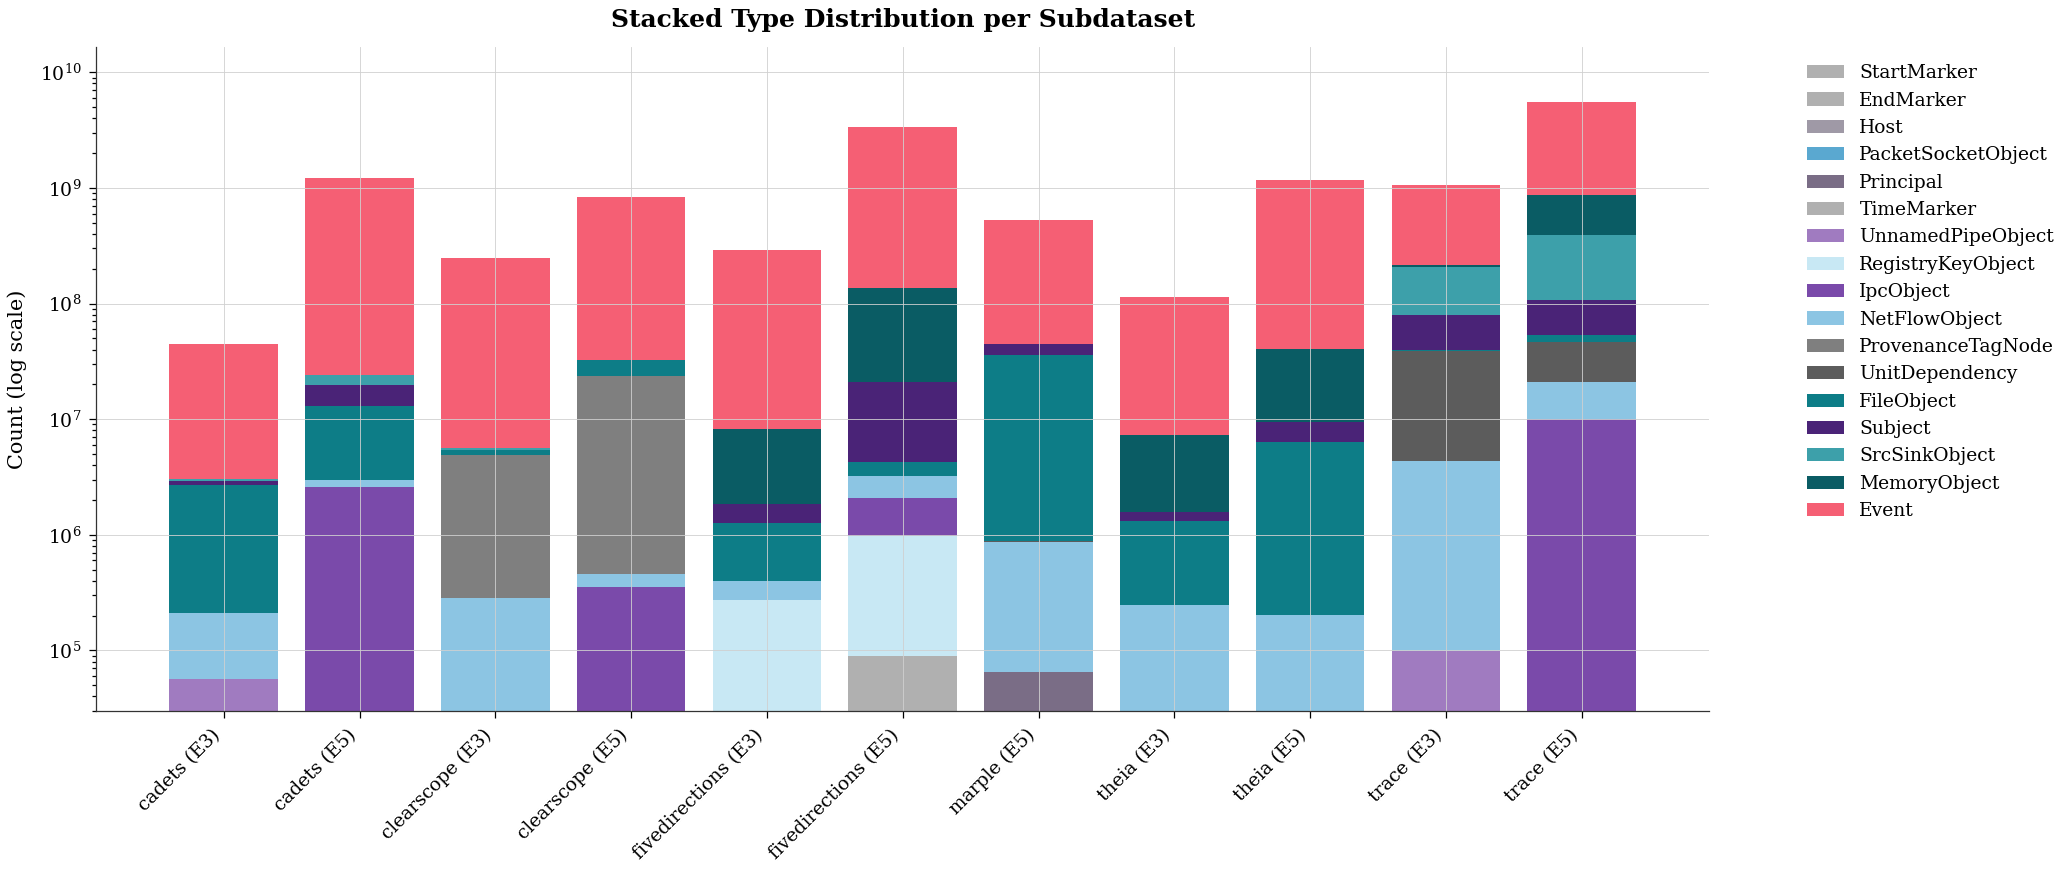

In [2]:
data_models = ["cdm20.json", "cdm18.json"]

type_colors = {
    # process-ish
    "Subject":              "#4a2377",
    "IpcObject":            "#7a4aaa",
    "UnnamedPipeObject":    "#a07bc0",

    # file-ish
    "FileObject":           "#0d7d87",
    "SrcSinkObject":        "#3da0aa",
    "MemoryObject":         "#0a5c64",

    # network-ish
    "NetFlowObject":        "#8cc5e3",
    "PacketSocketObject":   "#5aa8d0",

    # event
    "Event":                "#f55f74",

    # rare/meta
    "Principal":            "#7a6d86",
    "Host":                 "#9f99a6",

    # windows-only
    "RegistryKeyObject":    "#c8e8f4",

    # cdm metadata
    "TimeMarker":           "#b0b0b0",
    "StartMarker":          "#b0b0b0",
    "EndMarker":            "#b0b0b0",
    "ProvenanceTagNode":    "#7f7f7f",
    "UnitDependency":       "#5c5c5c",
}

bars = []
global_type_totals = defaultdict(int)

for data_model in data_models:
    summary_path = cache_path / "data_model_types_plot" / data_model
    with open(summary_path, "r") as fh:
        summary = json.load(fh)

    for subdataset, subdict in summary.items():
        type_counts = defaultdict(int)

        for key, val in subdict.items():
            c = sum(val.values())
            type_counts[key] += c
            global_type_totals[key] += c

        label = f"{subdataset} ({"E3" if data_model == "cdm18.json" else "E5"})"
        bars.append((label, dict(type_counts)))

bars = sorted(bars, key= lambda t: t[0])
types_sorted = sorted(global_type_totals, key=lambda t: global_type_totals[t])

fig, ax = plt.subplots(figsize=(14, 6))
x = list(range(len(bars)))
bottom = [0] * len(bars)

for t in types_sorted:
    values = [counts.get(t, 0) for _, counts in bars]
    ax.bar(x, values, bottom=bottom, label=t,color=type_colors.get(t, "#CCCCCC"),)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in bars], rotation=45, ha="right")

ax.set_ylabel("Count (log scale)")
ax.set_title("Stacked Type Distribution per Subdataset")

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Attack Tactics in datasets & Sub datasets

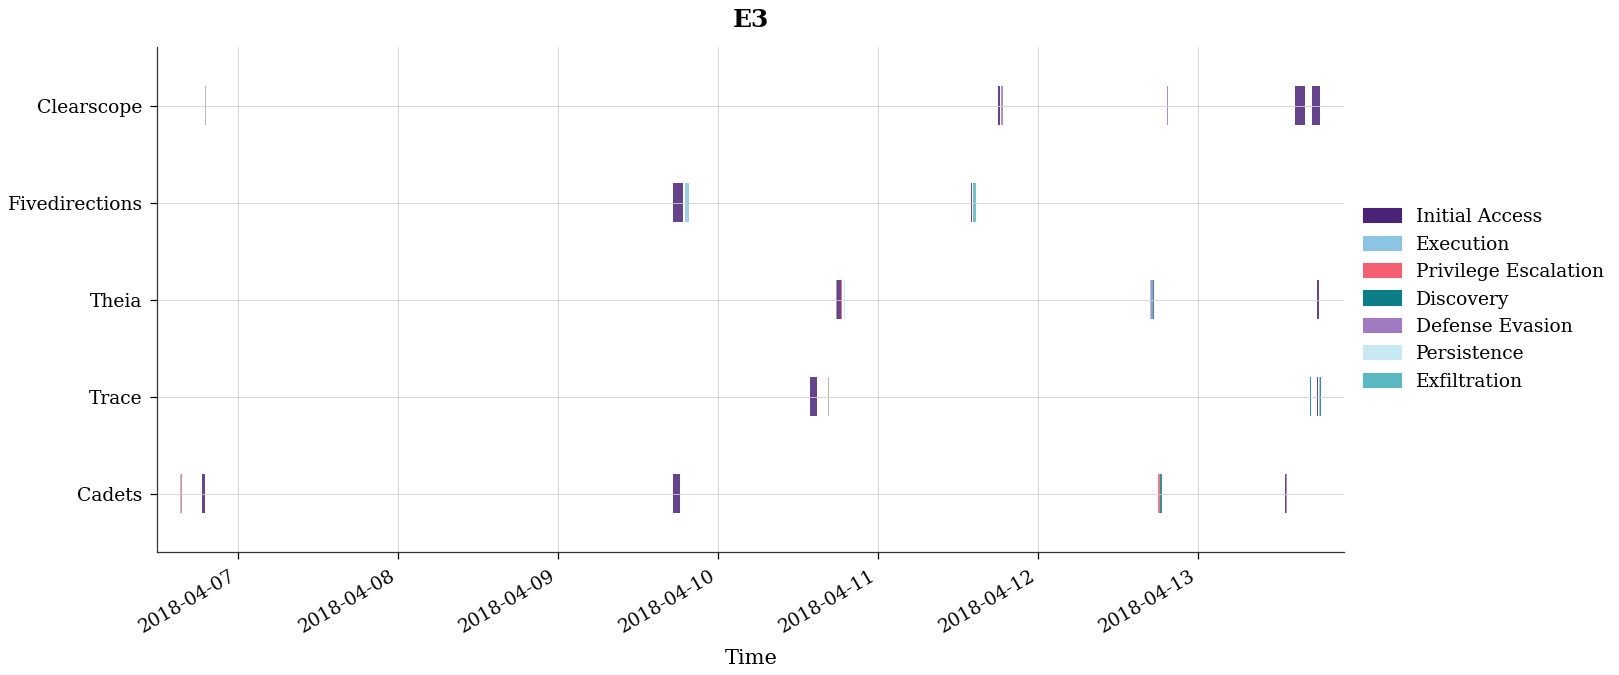

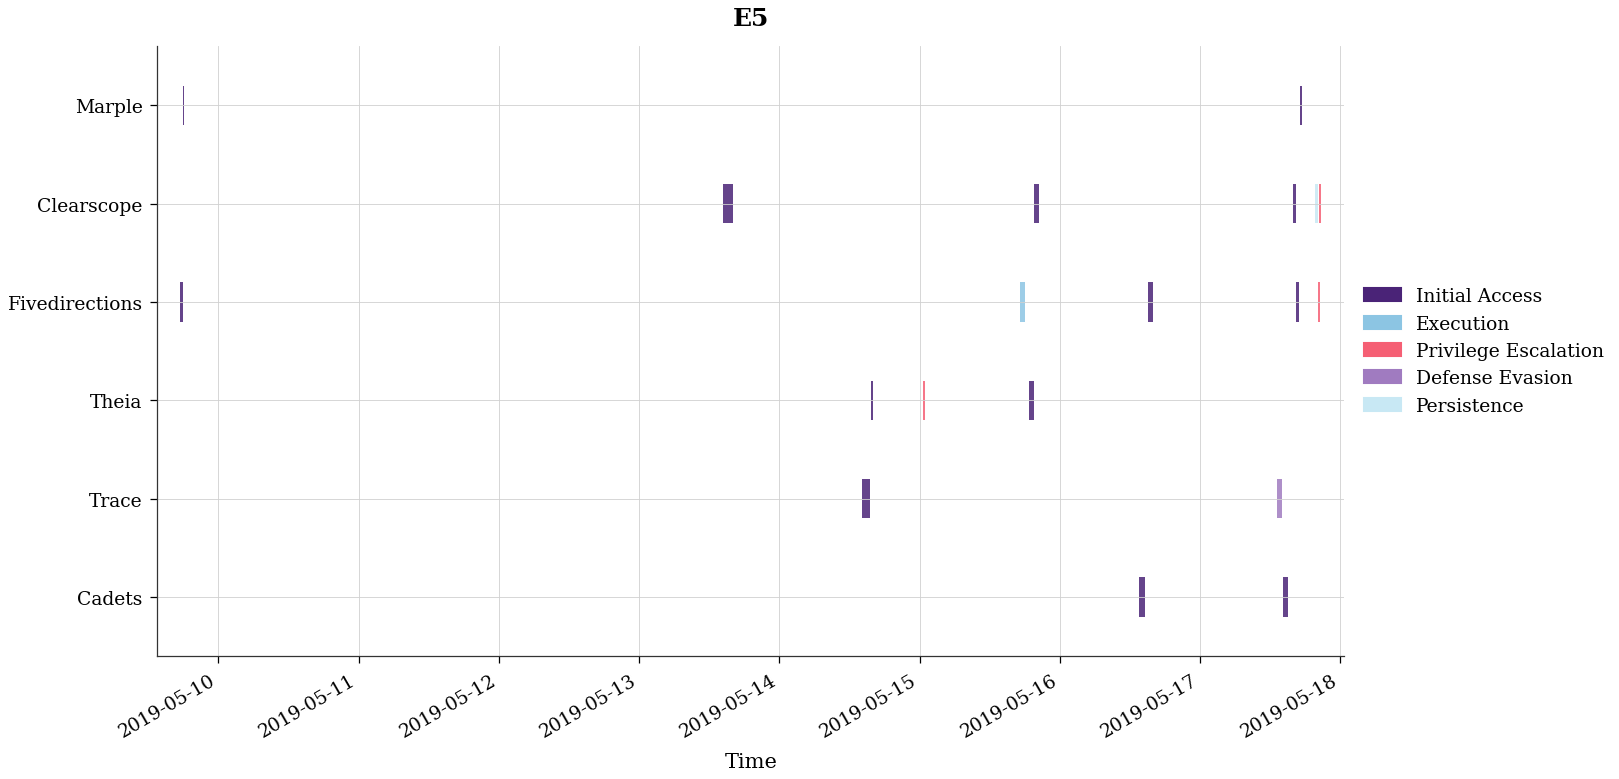

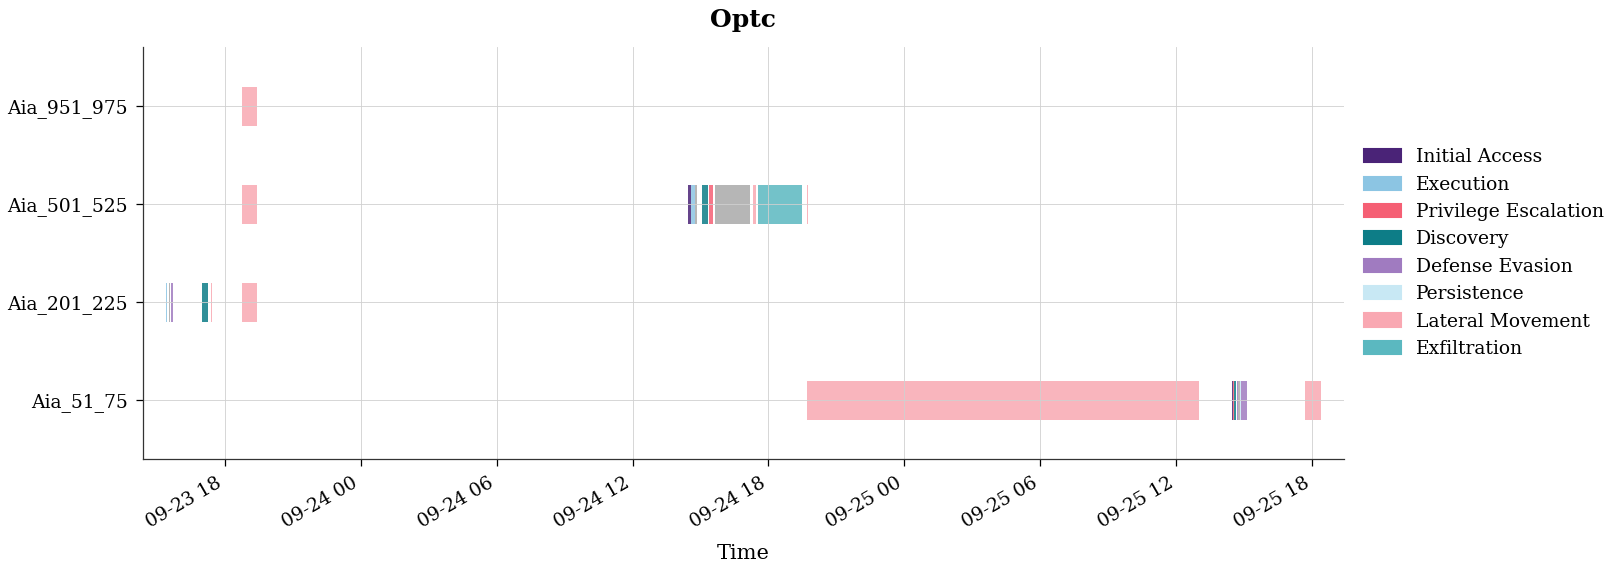

In [3]:
BAR_HEIGHT = 0.4   
BAR_ALPHA = 0.85
LABEL_PAD = 0.02
ROW_PAD = 0.6 
HEIGHT_PER_ROW = 0.7
HEIGHT_BASE = 1.2

TACTIC_COLORS = {
    "Initial Access":"#4a2377",
    "Execution":"#8cc5e3",
    "Privilege Escalation":"#f55f74",
    "Discovery":"#0d7d87",
    "Defense Evasion":"#a07bc0",
    "Persistence":"#c8e8f4",
    "Lateral Movement":"#f9a8b2",
    "Exfiltration":"#5bb8c0",
}
FALLBACK_COLOR = "#aaaaaa"

grouped = defaultdict(dict)
for (dataset, subdataset), registry in ALL_REGISTRIES.items():
    grouped[dataset][subdataset] = registry["attacks"]

for dataset, subdatasets in grouped.items():
    subdataset_names = list(subdatasets.keys())
    n_rows = len(subdataset_names)

    fig, ax = plt.subplots(figsize=(11, HEIGHT_BASE + HEIGHT_PER_ROW * n_rows))
    ax.set_title(dataset.capitalize())

    all_times = []

    for row_idx, (subdataset, attacks) in enumerate(subdatasets.items()):
        for attack in attacks:
            t_start = attack["start_edt"]
            t_end   = attack["end_edt"]
            color   = TACTIC_COLORS.get(attack["tactic"], FALLBACK_COLOR)

            x0 = mpl.dates.date2num(t_start)
            x1 = mpl.dates.date2num(t_end)
            all_times.extend([x0, x1])

            ax.broken_barh(
                [(x0, x1 - x0)],
                (row_idx - BAR_HEIGHT / 2, BAR_HEIGHT),
                facecolors=color,
                alpha=BAR_ALPHA,
            )

    time_range = max(all_times) - min(all_times)
    ax.set_xlim(min(all_times) - LABEL_PAD * time_range,
                max(all_times) + LABEL_PAD * time_range)
    ax.set_ylim(-ROW_PAD, n_rows - 1 + ROW_PAD)

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([s.capitalize() for s in subdataset_names])
    ax.xaxis_date()
    fig.autofmt_xdate()
    ax.set_xlabel("Time")

    seen_tactics = {a["tactic"] for attacks in subdatasets.values() for a in attacks}
    legend_handles = [
        mpatches.Patch(color=TACTIC_COLORS.get(t, FALLBACK_COLOR), label=t)
        for t in TACTIC_COLORS if t in seen_tactics
    ]
    ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.show()

# Smoothed raw event density comparison per dataset.
Loads cached JSON from RawEventDensityPlot and overlays all sub-datasets on one time axis


In [ ]:
CACHE_SUBDIR = "raw_event_density_plot"

BIN_WIDTH_S = 5 * 60 
BIN_WIDTH_NS = BIN_WIDTH_S * 10**9
SMOOTHING_WINDOW = 12

DATASETS = {
    "e3": ["cadets", "clearscope", "fivedirections", "theia", "trace"],
    "e5": ["cadets", "clearscope", "fivedirections", "marple", "theia", "trace"],
    "optc": ["AIA-51-75", "AIA-201-225", "AIA-501-525", "AIA-951-975"],
}

def _load_density_cache(dataset: str, sub_dataset: str) -> dict[str, int] | None:
    path = cache_path / CACHE_SUBDIR / dataset / sub_dataset / "raw_event_density.json"
    if not path.exists():
        print(f"skip: {path}")
        return None
    with open(path, "r") as fh:
        return json.load(fh)

def _to_dense_rate(data: dict[str, int]) -> tuple[list[datetime], np.ndarray]:
    ns_counts = {
        int(datetime.fromisoformat(k).timestamp() * 1e9): v
        for k, v in data.items()
    }
    sorted_ns = sorted(ns_counts.keys())
    t_min, t_max = sorted_ns[0], sorted_ns[-1]

    all_bins = list(range(t_min, t_max + BIN_WIDTH_NS, BIN_WIDTH_NS))
    dts = [datetime.fromtimestamp(b / 1e9, tz=timezone.utc) for b in all_bins]
    counts = np.array([ns_counts.get(b, 0) for b in all_bins], dtype=float)
    rates = counts / BIN_WIDTH_S
    return dts, rates

def _smooth(arr: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return arr
    kernel = np.ones(window) / window
    # pad edges
    padded = np.pad(arr, (window // 2, window - 1 - window // 2), mode="edge")
    return np.convolve(padded, kernel, mode="valid")

def plot_density_comparison(
    dataset: str,
    log_scale: bool = False,
    smoothing_window: int = SMOOTHING_WINDOW,
    figsize: tuple[float, float] = (16, 5),
):
    sub_datasets = DATASETS[dataset]
    colors = palette()

    fig, ax = plt.subplots(figsize=figsize)

    for sub_ds, color in zip(sub_datasets, colors):
        data = _load_density_cache(dataset, sub_ds)
        if data is None:
            continue
        dts, rates = _to_dense_rate(data)
        smoothed = _smooth(rates, smoothing_window)
        ax.plot(dts, smoothed, linewidth=0.8, label=sub_ds, color=color) # type: ignore

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylabel("Events / second (log)")
    else:
        ax.set_ylabel("Events / second")

    ax.set_xlabel("Time (UTC)")
    ax.set_title(f"Raw Event Densities for {dataset.upper()}")
    ax.legend(loc="upper right")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)

    fig.tight_layout()
    return fig

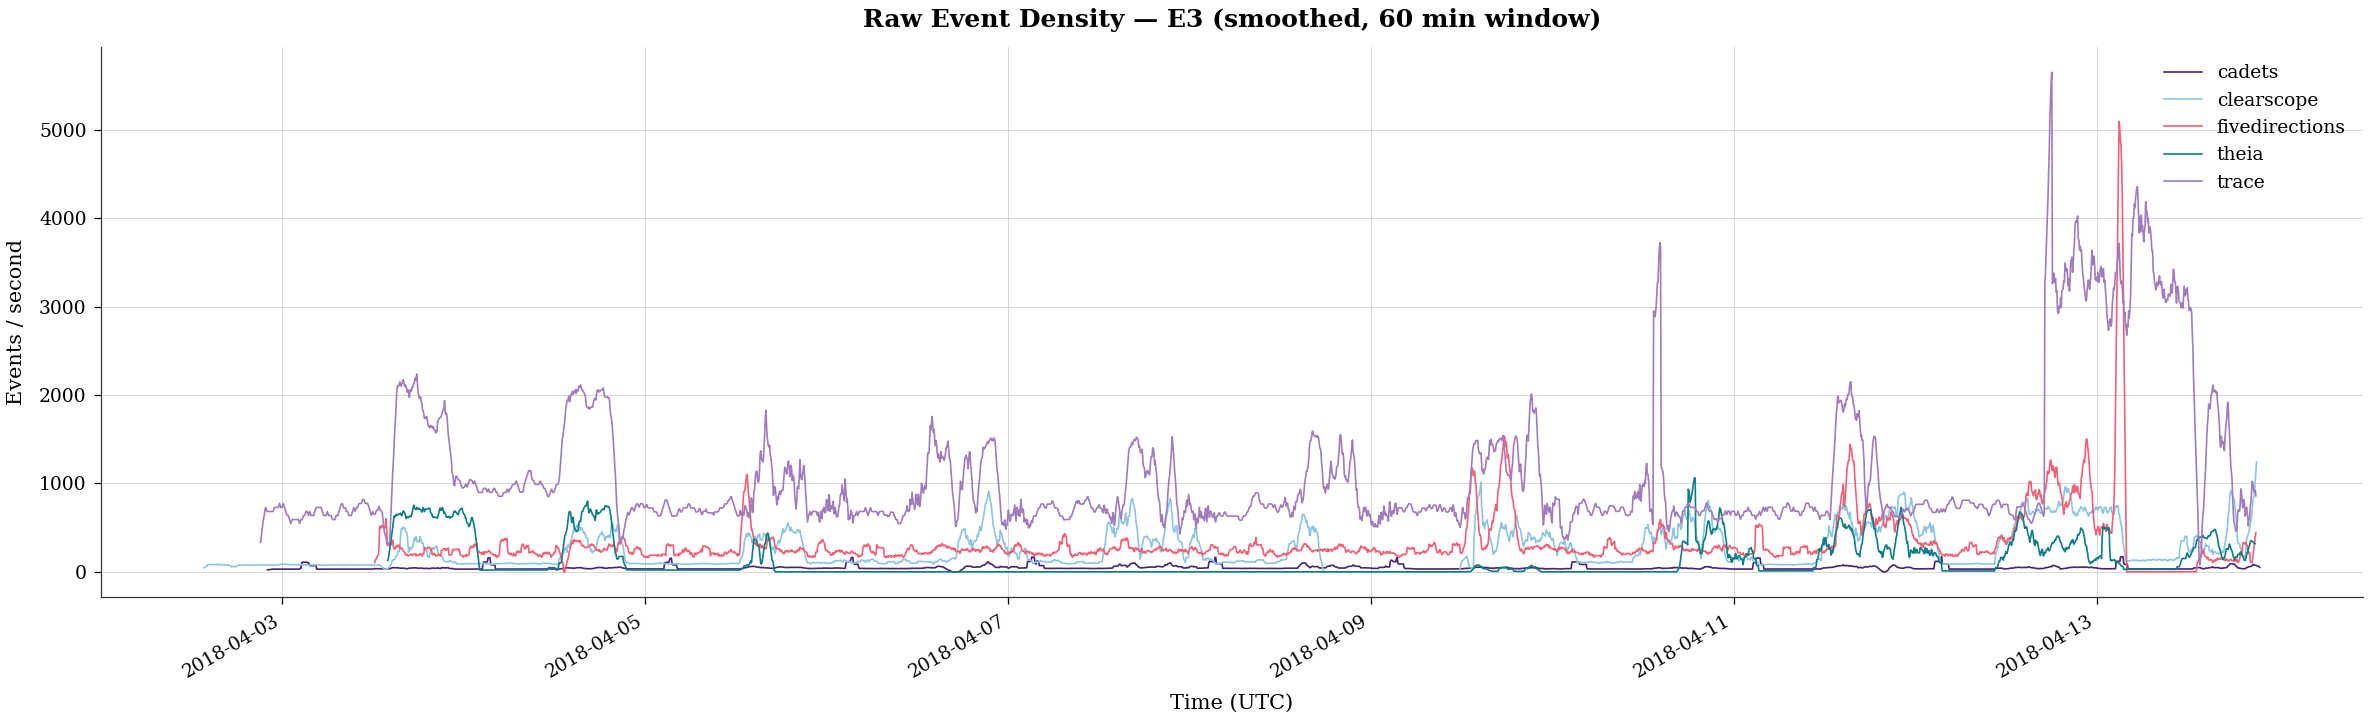

In [7]:
fig_e3 = plot_density_comparison("e3", log_scale=False)
plt.show()